# Tech Stack Recommender — EDA, Feature Engineering & Recommendation Logic

**Project 3: AI Recommendation Logic**
DecodeLabs Industrial Training Kit — Batch 2026

This notebook builds a **content-based recommendation system** that maps a user's
skills to the most relevant **tech job roles**, using:

1. Exploratory Data Analysis (EDA)
2. Feature Engineering (TF-IDF vectorization)
3. Recommendation Logic (Cosine Similarity)

Dataset: `IT_Job_Roles_Skills.csv`


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import re
from collections import Counter

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)


## 2. Load Dataset

In [ ]:
from pathlib import Path

possible_paths = []

if 'csv_path' in globals():
	possible_paths.append(Path(csv_path))

if 'candidate_paths' in globals():
	possible_paths.extend(Path(path) for path in candidate_paths)

search_roots = [Path.cwd(), *Path.cwd().parents]
for root in search_roots:
	possible_paths.append(root / 'IT_Job_Roles_Skills.csv')
	possible_paths.extend(root.rglob('IT_Job_Roles_Skills.csv'))
	possible_paths.extend(root.rglob('IT_Job_Roles_Skills.csv'))

csv_file = next((path for path in possible_paths if path.exists()), None)

if csv_file is None:
	raise FileNotFoundError(
		"Could not find 'IT_Job_Roles_Skills.csv'. "
		"Check the notebook working directory or set 'csv_path' to the correct file."
	)

try:
	df = pd.read_csv(csv_file, encoding="utf-8")
except UnicodeDecodeError:
	df = pd.read_csv(csv_file, encoding="cp1252")
print(f'Loaded from: {csv_file}')
print(f'Shape: {df.shape}')
print('\nTarget distribution (original 5-class):')
df.head()

print("Shape:", df.shape)
df.head()


Loaded from: d:\University\Projects\SkillSync-Tech-Role-Recommendation-Engine\dataset\IT_Job_Roles_Skills.csv
Shape: (493, 4)

Target distribution (original 5-class):
Shape: (493, 4)


,Job Title,Job Description,Skills,Certifications
0,Admin Big Data,Responsible for managing and overseeing big da...,"Hadoop, Spark, MapReduce, Data Lakes, Data War...","Cloudera Certified Professional (CCP), Hortonw..."
1,Ansible Operations Engineer,Focuses on automating IT processes using Ansib...,"Ansible, Linux, Automation, Cloud Platforms, C...",Red Hat Certified Specialist in Ansible Automa...
2,Artifactory Administrator,Manages the Artifactory repository for build a...,"Artifactory, CI/CD, Jenkins, Docker, Maven, Gr...","JFrog Artifactory Certification, DevOps Instit..."
3,Artificial Intelligence / Machine Learning Leader,"Leads AI/ML projects and teams, defining strat...","AI Strategy, Machine Learning, Team Management...","AI-900: Microsoft Azure AI Fundamentals, Certi..."
4,Artificial Intelligence / Machine Learning Sr....,Senior role overseeing multiple AI/ML initiati...,"AI Strategy, Machine Learning, Team Management...",Certified Artificial Intelligence Practitioner...


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 493 entries, 0 to 492
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Job Title        493 non-null    object
 1   Job Description  493 non-null    object
 2   Skills           493 non-null    object
 3   Certifications   493 non-null    object
dtypes: object(4)
memory usage: 15.5+ KB


In [6]:
df.isnull().sum()

Job Title          0
Job Description    0
Skills             0
Certifications     0
dtype: int64

## 3. Data Cleaning

- Drop rows with missing critical fields (Job Title or Skills)
- Remove duplicate job titles
- Standardize text casing


In [7]:
# Drop rows missing essential fields
df = df.dropna(subset=["Job Title", "Skills"]).reset_index(drop=True)

# Standardize job title casing (Title Case) and strip whitespace
df["Job Title"] = df["Job Title"].str.strip().str.title()

# Remove exact duplicate job titles, keep first occurrence
before = len(df)
df = df.drop_duplicates(subset=["Job Title"]).reset_index(drop=True)
after = len(df)
print(f"Removed {before - after} duplicate job titles. Remaining rows: {after}")

df.head()


Removed 141 duplicate job titles. Remaining rows: 352


,Job Title,Job Description,Skills,Certifications
0,Admin Big Data,Responsible for managing and overseeing big da...,"Hadoop, Spark, MapReduce, Data Lakes, Data War...","Cloudera Certified Professional (CCP), Hortonw..."
1,Ansible Operations Engineer,Focuses on automating IT processes using Ansib...,"Ansible, Linux, Automation, Cloud Platforms, C...",Red Hat Certified Specialist in Ansible Automa...
2,Artifactory Administrator,Manages the Artifactory repository for build a...,"Artifactory, CI/CD, Jenkins, Docker, Maven, Gr...","JFrog Artifactory Certification, DevOps Instit..."
3,Artificial Intelligence / Machine Learning Leader,"Leads AI/ML projects and teams, defining strat...","AI Strategy, Machine Learning, Team Management...","AI-900: Microsoft Azure AI Fundamentals, Certi..."
4,Artificial Intelligence / Machine Learning Sr....,Senior role overseeing multiple AI/ML initiati...,"AI Strategy, Machine Learning, Team Management...",Certified Artificial Intelligence Practitioner...


## 4. Exploratory Data Analysis (EDA)

### 4.1 Dataset Overview


In [8]:
print("Total unique job roles:", df['Job Title'].nunique())
print("Total columns:", df.shape[1])
print("Columns:", list(df.columns))


Total unique job roles: 352
Total columns: 4
Columns: ['Job Title', 'Job Description', 'Skills', 'Certifications']


### 4.2 Skill Frequency Analysis

Split the comma-separated `Skills` column into individual skills and find the most common ones across all job roles.

In [9]:
def split_skills(skill_string):
    if pd.isna(skill_string):
        return []
    return [s.strip() for s in skill_string.split(",") if s.strip()]

df["Skills_List"] = df["Skills"].apply(split_skills)
df["Num_Skills"] = df["Skills_List"].apply(len)

all_skills = [skill for skills in df["Skills_List"] for skill in skills]
skill_counts = Counter(all_skills)

print("Total unique skills mentioned:", len(skill_counts))
print("\nTop 20 most common skills:")
for skill, count in skill_counts.most_common(20):
    print(f"  {skill}: {count}")


Total unique skills mentioned: 617

Top 20 most common skills:
  Cloud Computing: 69
  Automation: 52
  CI/CD: 52
  Python: 47
  Linux: 45
  Git: 41
  SQL: 40
  Security: 39
  Docker: 38
  Networking: 38
  Scripting: 37
  Project Management: 36
  Java: 34
  AWS: 32
  Kubernetes: 31
  Team Leadership: 30
  Azure: 29
  JavaScript: 29
  Troubleshooting: 24
  HTML: 22


C:\Users\R Kapoor\AppData\Local\Temp\ipykernel_17360\2485770533.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_skills, y="Skill", x="Count", palette="viridis")


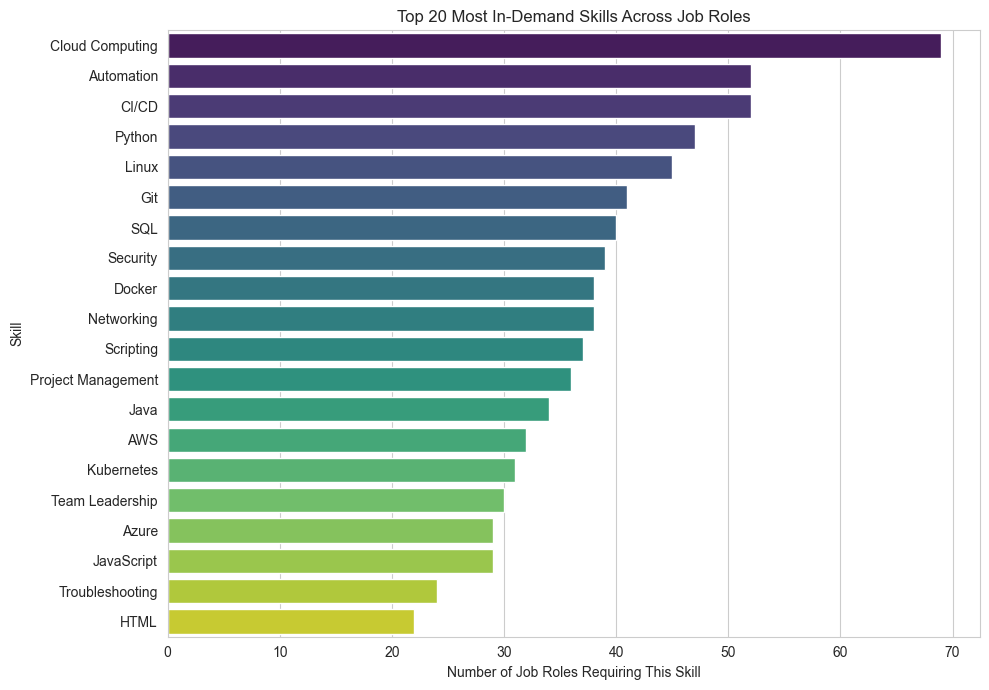

In [25]:
# Visualize top 20 skills
top_skills = pd.DataFrame(skill_counts.most_common(20), columns=["Skill", "Count"])

plt.figure(figsize=(10, 7))
sns.barplot(data=top_skills, y="Skill", x="Count", palette="viridis")
plt.title("Top 20 Most In-Demand Skills Across Job Roles")
plt.xlabel("Number of Job Roles Requiring This Skill")
plt.ylabel("Skill")
plt.tight_layout()
plt.savefig("../images/top_skills.png", dpi=100)
plt.show()


### 4.3 Number of Skills per Job Role

How many skills does a typical job role require?

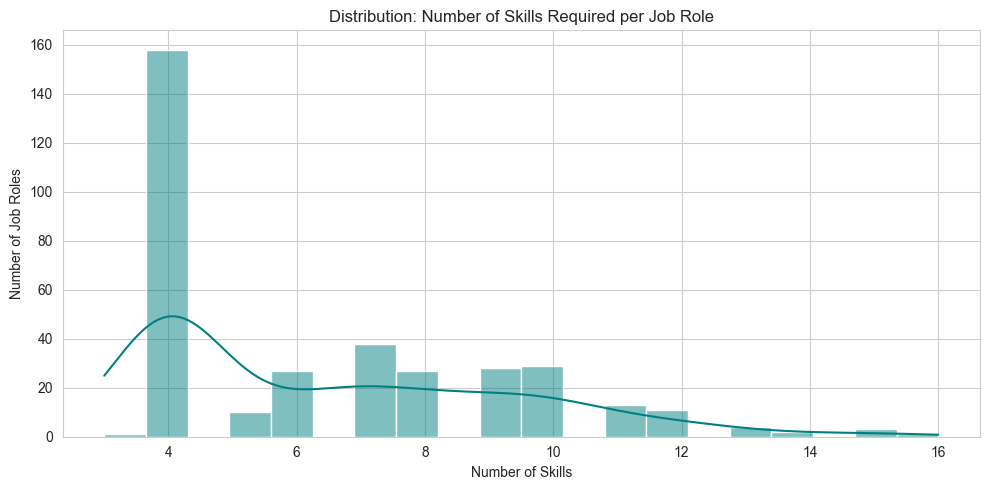

count    352.000000
mean       6.497159
std        2.831446
min        3.000000
25%        4.000000
50%        6.000000
75%        9.000000
max       16.000000
Name: Num_Skills, dtype: float64


In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Num_Skills"], bins=20, kde=True, color="teal")
plt.title("Distribution: Number of Skills Required per Job Role")
plt.xlabel("Number of Skills")
plt.ylabel("Number of Job Roles")
plt.tight_layout()
plt.savefig("../images/skills_per_role.png", dpi=100)
plt.show()

print(df["Num_Skills"].describe())


### 4.4 Job Description Length Analysis

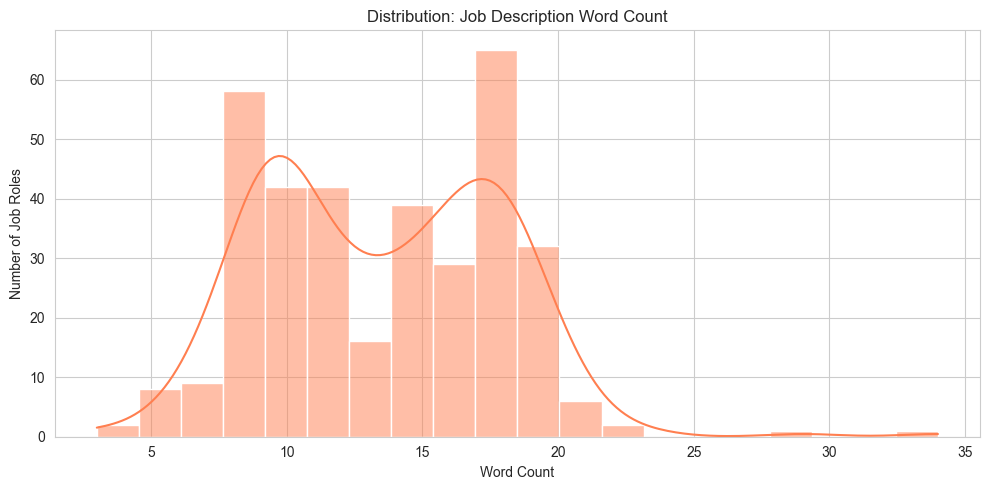

In [27]:
df["Description_Length"] = df["Job Description"].fillna("").apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 5))
sns.histplot(df["Description_Length"], bins=20, kde=True, color="coral")
plt.title("Distribution: Job Description Word Count")
plt.xlabel("Word Count")
plt.ylabel("Number of Job Roles")
plt.tight_layout()
plt.savefig("../images/description_length.png", dpi=100)
plt.show()


### 4.5 Certification Availability

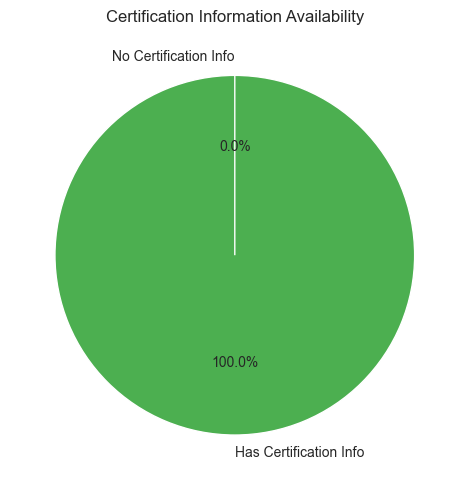

In [28]:
has_cert = df["Certifications"].notna().sum()
no_cert = df["Certifications"].isna().sum()

plt.figure(figsize=(5, 5))
plt.pie([has_cert, no_cert], labels=["Has Certification Info", "No Certification Info"],
        autopct="%1.1f%%", colors=["#4CAF50", "#E0E0E0"], startangle=90)
plt.title("Certification Information Availability")
plt.tight_layout()
plt.savefig("../images/certification_pie.png", dpi=100)
plt.show()


## 5. Feature Engineering

To compare a user's skills against every job role mathematically, we need to convert
text (skills) into numeric vectors.

### Why TF-IDF?
- **Term Frequency (TF)**: how often a skill appears within a role's skill list
- **Inverse Document Frequency (IDF)**: penalizes skills that appear across *almost every*
  role (e.g. "Communication", "Cloud Computing") and rewards specific, distinguishing
  skills (e.g. "Kubernetes", "TensorFlow")

This avoids the flaw of simple binary/Jaccard matching, where common generic skills
would dominate the similarity score.


In [14]:
# Build a clean text representation of skills for each job role
# (TF-IDF treats this like a 'document' of skill-words)
def clean_skills_text(skills_list):
    cleaned = [re.sub(r'[^a-zA-Z0-9\s]', '', s).strip().lower().replace(" ", "_") for s in skills_list]
    return " ".join(cleaned)

df["Skills_Text"] = df["Skills_List"].apply(clean_skills_text)
df[["Job Title", "Skills_Text"]].head()


,Job Title,Skills_Text
0,Admin Big Data,hadoop spark mapreduce data_lakes data_warehou...
1,Ansible Operations Engineer,ansible linux automation cloud_platforms cicd ...
2,Artifactory Administrator,artifactory cicd jenkins docker maven gradle b...
3,Artificial Intelligence / Machine Learning Leader,ai_strategy machine_learning team_management p...
4,Artificial Intelligence / Machine Learning Sr....,ai_strategy machine_learning team_management p...


In [15]:
# Fit TF-IDF Vectorizer on the skills corpus
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df["Skills_Text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size (unique skill tokens):", len(vectorizer.vocabulary_))


TF-IDF matrix shape: (352, 614)
Vocabulary size (unique skill tokens): 614


In [16]:
# Inspect which skills get the HIGHEST IDF weight (rare/specific = high impact)
idf_scores = pd.DataFrame({
    "skill": vectorizer.get_feature_names_out(),
    "idf_weight": vectorizer.idf_
}).sort_values("idf_weight", ascending=False)

print("Top 15 highest-weighted (most specific/rare) skills:")
print(idf_scores.head(15).to_string(index=False))

print("\nTop 15 lowest-weighted (most generic/common) skills:")
print(idf_scores.tail(15).to_string(index=False))


Top 15 highest-weighted (most specific/rare) skills:
                     skill  idf_weight
                    zabbix    6.173321
            2d3d_animation    6.173321
                 xl_deploy    6.173321
  vulnerability_assessment    6.173321
                      vsam    6.173321
            vr_development    6.173321
                       vpc    6.173321
               visualforce    6.173321
       visual_storytelling    6.173321
visual_effects_supervision    6.173321
             visual_design    6.173321
          video_production    6.173321
         anypoint_platform    6.173321
       animation_direction    6.173321
            android_studio    6.173321

Top 15 lowest-weighted (most generic/common) skills:
             skill  idf_weight
        kubernetes    3.400732
               aws    3.369960
              java    3.311120
project_management    3.255550
         scripting    3.228882
        networking    3.202906
            docker    3.202906
          security   

## 6. Recommendation Logic (Cosine Similarity)

**Pipeline (Input → Process → Output):**
1. **Ingestion**: take user's input skills
2. **Scoring**: transform user skills into the same TF-IDF vector space, then compute
   Cosine Similarity against every job role's vector
3. **Sorting**: rank roles by similarity score, descending
4. **Filtering**: return the Top-N most relevant roles


In [17]:
def recommend_jobs(user_skills, top_n=3):
    """
    user_skills: list of strings, e.g. ["Python", "Cloud Computing", "Automation"]
    Returns a DataFrame of the top_n matching job roles with similarity scores.
    """
    # Step 1: Ingestion -> clean the same way as training data
    user_text = clean_skills_text(user_skills)

    # Step 2: Scoring -> vectorize user input using the SAME fitted vectorizer
    user_vector = vectorizer.transform([user_text])
    similarity_scores = cosine_similarity(user_vector, tfidf_matrix).flatten()

    # Step 3: Sorting
    df_temp = df.copy()
    df_temp["Similarity_Score"] = similarity_scores
    ranked = df_temp.sort_values("Similarity_Score", ascending=False)

    # Step 4: Filtering -> Top-N, excluding zero-score (no overlap at all) matches
    top_matches = ranked[ranked["Similarity_Score"] > 0].head(top_n)

    return top_matches[["Job Title", "Skills", "Similarity_Score"]].reset_index(drop=True)


In [18]:
# Test the recommender
test_skills = ["Python", "Cloud Computing", "Automation"]
results = recommend_jobs(test_skills, top_n=3)
print(f"User skills: {test_skills}\n")
results


User skills: ['Python', 'Cloud Computing', 'Automation']



,Job Title,Skills,Similarity_Score
0,Ansible Automation Engineer,"Ansible, Automation, Infrastructure as Code, C...",0.452455
1,Cloud Automation Engineer,"Cloud Computing, Automation, Terraform, Ansibl...",0.448784
2,Senior Ansible Development Engineer,"Ansible, Automation, Infrastructure as Code, C...",0.422615


In [19]:
# Another test case
test_skills_2 = ["Docker", "Kubernetes", "CI/CD", "AWS"]
results_2 = recommend_jobs(test_skills_2, top_n=5)
print(f"User skills: {test_skills_2}\n")
results_2


User skills: ['Docker', 'Kubernetes', 'CI/CD', 'AWS']



,Job Title,Skills,Similarity_Score
0,Kubernetes Operations Engineer,"Kubernetes, Docker, Linux, Cloud Computing, AW...",0.649947
1,Kubernetes Administrator,"Kubernetes, Docker, Linux, Cloud Computing, AW...",0.649947
2,Kubernetes Engineer,"Kubernetes, Docker, Linux, Cloud Computing, AW...",0.649947
3,Devops Architect,"Cloud Computing, AWS, Azure, Google Cloud, Doc...",0.539148
4,Aws Devops Engineer,"AWS, DevOps, CI/CD, Terraform, Ansible, CloudF...",0.515034


In [20]:
# Cold-start handling: if no overlap is found, fall back to most common/popular roles
def recommend_jobs_with_fallback(user_skills, top_n=3):
    results = recommend_jobs(user_skills, top_n=top_n)
    if results.empty:
        print("No direct skill overlap found. Showing trending/popular roles instead.")
        fallback = df.sample(top_n, random_state=42)[["Job Title", "Skills"]].reset_index(drop=True)
        fallback["Similarity_Score"] = 0.0
        return fallback
    return results

# Test cold start with nonsense input
print(recommend_jobs_with_fallback(["Underwater Basket Weaving"], top_n=3))


No direct skill overlap found. Showing trending/popular roles instead.
                   Job Title  \
0               Web Designer   
1       Javascript Developer   
2  Cloud Automation Engineer   

                                              Skills  Similarity_Score  
0  Web Design, Graphic Design, UI/UX Principles, ...               0.0  
1  JavaScript, HTML, CSS, React, Angular, Vue.js,...               0.0  
2  Cloud Computing, Automation, Terraform, Ansibl...               0.0  


## 7. Save Artifacts for the Streamlit App

We persist the cleaned dataframe, the fitted vectorizer, and the TF-IDF matrix so the
Streamlit GUI can load them instantly without retraining.


In [24]:
joblib.dump(vectorizer, "../models/vectorizer.joblib")
joblib.dump(tfidf_matrix, "../models/tfidf_matrix.joblib")
df.to_pickle("../models/job_roles_processed.pkl")

print("Artifacts saved: vectorizer.joblib, tfidf_matrix.joblib, job_roles_processed.pkl")


Artifacts saved: vectorizer.joblib, tfidf_matrix.joblib, job_roles_processed.pkl


## 8. Conclusion

- Cleaned and explored a real-world IT job roles dataset
- Identified the most in-demand skills and typical role complexity
- Engineered TF-IDF features that weigh specific skills higher than generic ones
- Built a working content-based recommendation engine using Cosine Similarity
- Added a cold-start fallback for skills with no dataset overlap
- Saved all artifacts for reuse in the Streamlit GUI (`app.py`)
